![Astrofisica Computacional](../../new_logo.png)

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Nebulosa de Orión (M42)
</h3>

<p>
La Nebulosa de Orión, también conocida como <b>Messier 42 (M42)</b> o <b>NGC 1976</b>, es una nebulosa difusa situada al sur del cinturón de Orión.
</p>

<p>
Es una de las regiones de formación estelar más cercanas y brillantes a la Tierra, por lo que constituye uno de los objetos más estudiados en astronomía. Su intensa emisión proviene del gas ionizado por estrellas jóvenes y masivas que se encuentran en su interior.
</p>

<p>
Gracias a su proximidad y brillo, la Nebulosa de Orión es un laboratorio natural ideal para investigar procesos de formación estelar, evolución de nubes moleculares y dinámica del medio interestelar.
</p>

</div>

# Computational Astrophysics – `FITS` Files (Images) I

## Dr. rer. nat. Jose Ivan Campos Rozo<sup>1,2</sup>

1. Astronomical Institute of the Czech Academy of Sciences\
   Department of Solar Physics\
   Ondřejov, Czec Republic

2. Observatorio Astronómico Nacional\
   Facultad de Ciencias\
   Universidad Nacional de Colombia

e-mail: jicamposr@unal.edu.co & rozo@asu.cas.cz)

---
Taken from previous lectures of this course.


### Summary

In this notebook we will use `astropy` to read a .fits file and display its contents as an astronomical image.

---

The [Flexible Image Transport System](https://fits.gsfc.nasa.gov/fits_documentation.html) (FITS) format is widely used within the astronomical community to store images, spectra, tables, etc.

The FITS format was invented in the astronomy environment and is still used due to its simple, efficient and logical structure and because the data is **NOT compressed**. This means that the data is stored at the original resolution and no specialized software is required to uncompress and access it.

---

In this notebook, we will use a .fits image of the Horse Head Nebula, obtained from

http://data.astropy.org/tutorials/FITS-images/HorseHead.fits


Detailed information on handling .fits files with `astropy` can be found at

http://docs.astropy.org/en/stable/io/fits/index.html

---

## 1. Open and close a .fits file

The first step in accessing the file is to open it using the `astropy.io.fits.open()` function. This function returns an object called **HDUList** (**H**eader **D**ata **U**nits **List**). Here we will call this object `hdul`.

In [37]:
from matplotlib import pyplot as plt
from astropy.io import fits
import numpy as np
%matplotlib inline


hdul = fits.open('m42_40min_red.fits 2')
hdul

The `.info()` method will return a summary of the contents of the FITS file,

In [24]:
hdul.info()

Filename: m42_40min_red.fits 2
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     129   (2376, 2381)   int16   


In general, there can be several information units, denoted by the names `hdul[0]`, `hdul[1]`, etc. The `hdul[0]` drive is called the PRIMARY drive and usually contains the initial access information for the file (eg number of cards, dimensions, format, etc.). In the other units there is additional relevant information, such as masks, filters, etc.

After accessing this information, and if no other action is to be taken, it is advisable to close the file to avoid corrupting it,

In [25]:
hdul.close()

An efficient way to access the information, opening and closing the file automatically, is

In [38]:
with fits.open('m42_40min_red.fits 2') as hdul:
    hdul.info()

Filename: m42_40min_red.fits 2
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     129   (2376, 2381)   int16   


### 1.1. Headers and Data (Headers and Data)

Each HDU object contains the `.header` and `.data` attributes. Using the `header` attribute it is possible to access the header of the HDU object, which contains all the information of this data unit,

In [55]:
hdul[0].header

SIMPLE  =                    T /FITS header                                     
BITPIX  =                   16 /No.Bits per pixel                               
NAXIS   =                    2 /No.dimensions                                   
NAXIS1  =                 2376 /Length X axis                                   
NAXIS2  =                 2381 /Length Y axis                                   
EXTEND  =                    T /                                                
DATE    = '09/07/04          ' /Date of FITS file creation                      
ORIGIN  = 'CASB -- STScI     ' /Origin of FITS image                            
PLTLABEL= 'OR14052           ' /Observatory plate label                         
PLATEID = 'A0JP              ' /GSSS Plate ID                                   
REGION  = 'ER768             ' /GSSS Region Name                                
DATE-OBS= '1990/12/22        ' /UT date of Observation                          
UT      = '#################

Here you will find a lot of information, such as: ORIGIN, DATE, RA, DEC, TELESCOPE, FILTER, etc. To access each of them you can use

In [57]:
hdul[0].header

SIMPLE  =                    T /FITS header                                     
BITPIX  =                   16 /No.Bits per pixel                               
NAXIS   =                    2 /No.dimensions                                   
NAXIS1  =                 2376 /Length X axis                                   
NAXIS2  =                 2381 /Length Y axis                                   
EXTEND  =                    T /                                                
DATE    = '09/07/04          ' /Date of FITS file creation                      
ORIGIN  = 'CASB -- STScI     ' /Origin of FITS image                            
PLTLABEL= 'OR14052           ' /Observatory plate label                         
PLATEID = 'A0JP              ' /GSSS Plate ID                                   
REGION  = 'ER768             ' /GSSS Region Name                                
DATE-OBS= '1990/12/22        ' /UT date of Observation                          
UT      = '#################

NOTE: To fully understand the information stored, you must refer to the source of the file (database, web page, documentation, etc.)

---

On the other hand, the `data` attribute gives access to the information stored in the HDU. For example, in the specific case we are working on, we will assign this information to the image_data variable.

**Note: It is important to assign this information before closing the file!**

In [41]:
hdul = fits.open('m42_40min_red.fits 2')
image_data = hdul[0].data
hdul.close()

The information has been saved as a NumPy array,

In [42]:
type(image_data)

numpy.ndarray

In [43]:
image_data.shape

(2381, 2376)

In this way we can easily access the data,

In [44]:
image_data[10:15 , 20:30]

array([[6817, 7096, 7096, 7655, 7725, 7166, 6747, 6467, 6712, 7271],
       [7096, 7376, 7376, 7935, 7725, 7166, 6747, 6467, 6712, 6712],
       [6886, 7166, 7306, 7026, 6956, 6677, 6258, 6258, 6153, 6432],
       [6607, 6886, 7026, 6747, 6677, 6956, 6258, 6258, 6153, 6991],
       [6327, 6327, 7166, 6607, 6817, 6817, 6397, 6397, 6852, 7131]],
      dtype='>i2')

We can also obtain important statistical information,

In [45]:
np.min(image_data)

np.int16(1845)

In [46]:
np.max(image_data)

np.int16(22512)

In [47]:
np.mean(image_data)

np.float64(14795.749599452456)

## 2. Image Display

For the file we are considering, the information stored corresponds to a photometric image of the nebula. In this way, we can use a function like [matplotlib.pyplot.imshow()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.imshow.html) to display the image

http://learn.astropy.org/rst-tutorials/FITS-images.html?highlight=filtertutorials

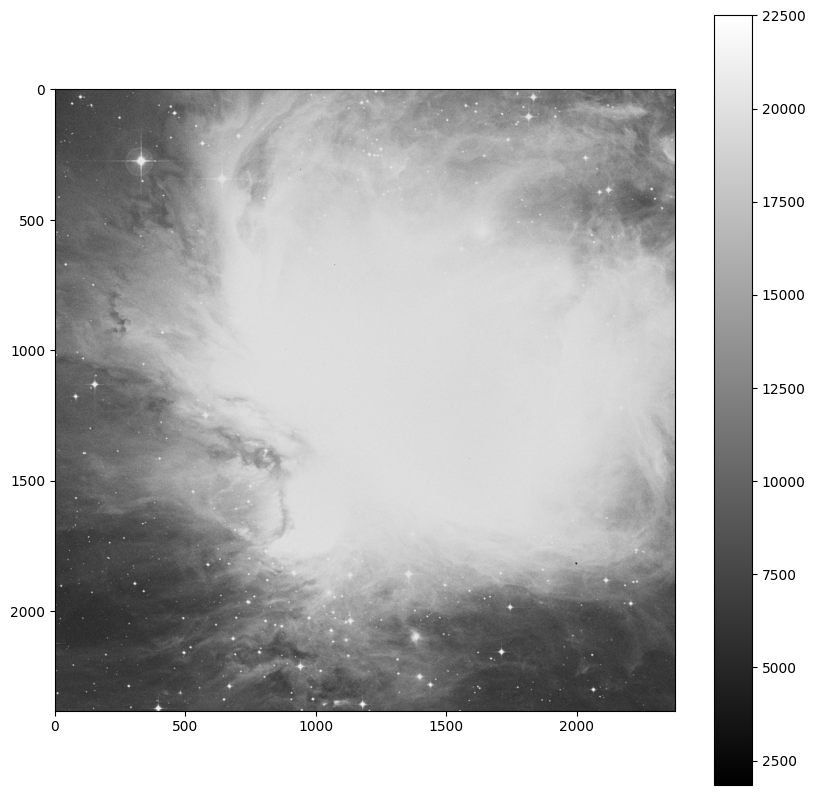

In [48]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='gray')
plt.colorbar()
plt.show()

The 'gray' color map can be changed. [There are multiple options](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

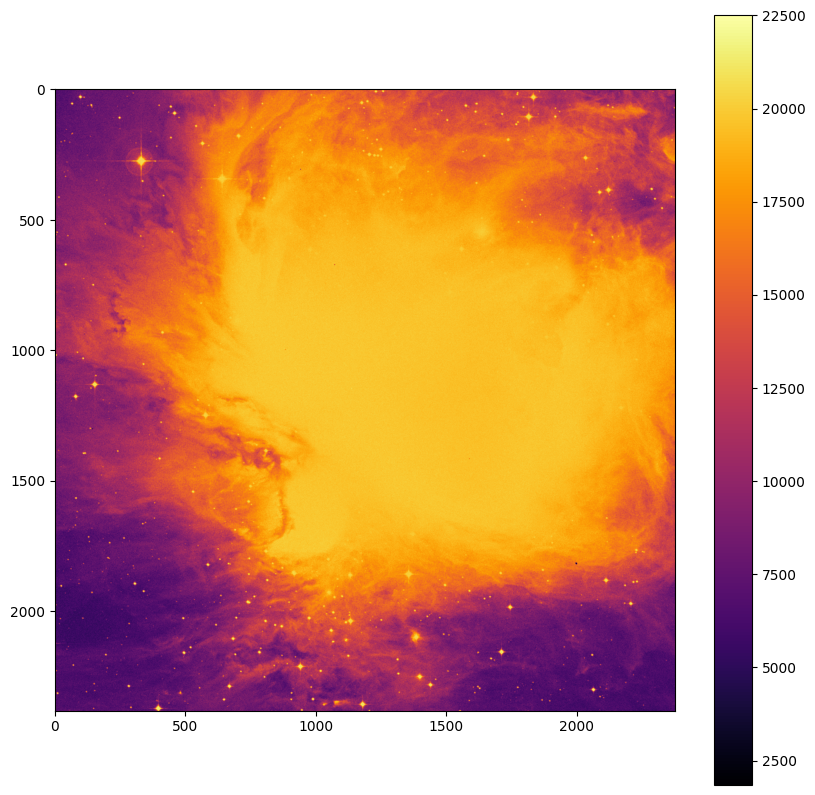

In [49]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='inferno')
plt.colorbar()
plt.show()

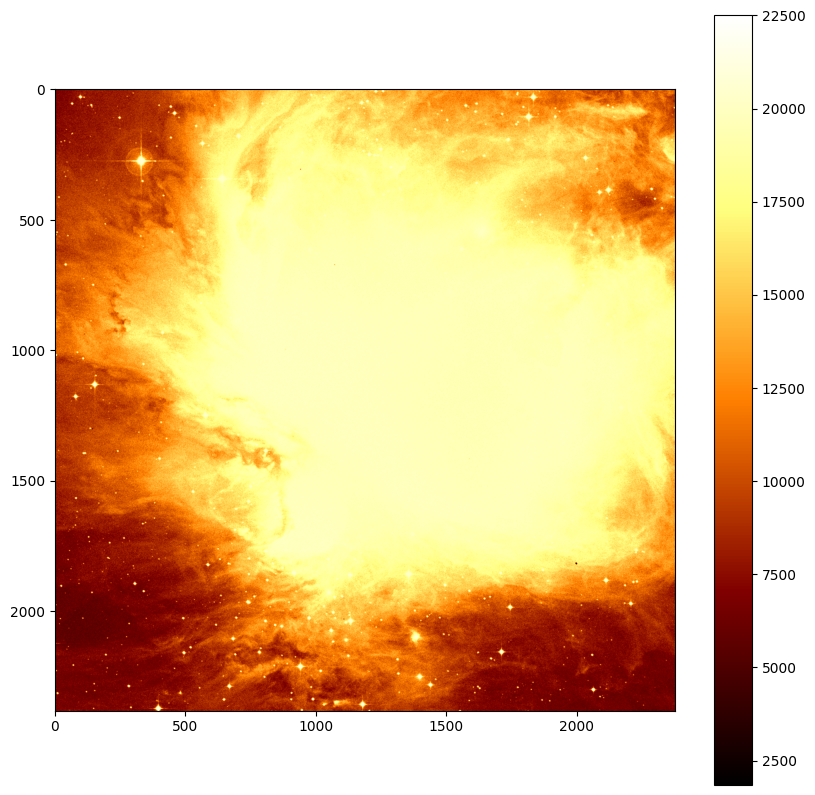

In [50]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='afmhot')
plt.colorbar()
plt.show()

Additionally, a logarithmic color scale can be used to highlight details using the [matplotlib.colors.LogNorm](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.colors.LogNorm.html) function.

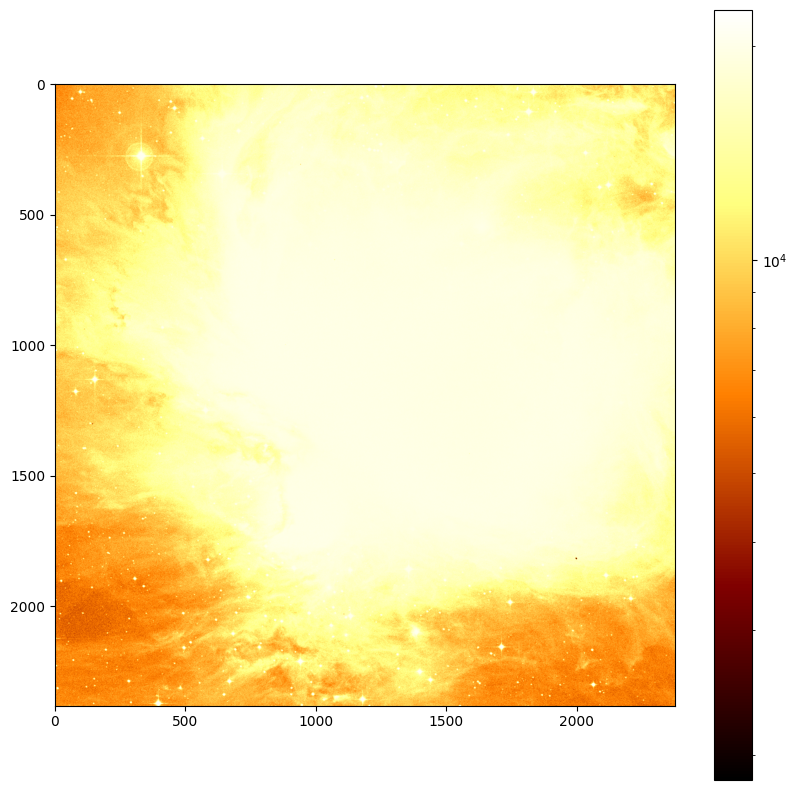

In [51]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='afmhot', norm=LogNorm())
plt.colorbar()
plt.show()

### 2.1. Histogram
The data in the 2D array can be flattened,

In [52]:
flat_data = image_data.flatten()

and with this a histogram can be built to visualize what values (colors) appear within the image [matplotlib.pyplot.hist()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.hist.html)

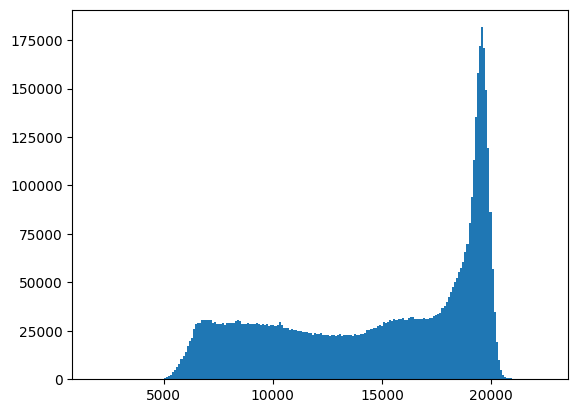

In [53]:
plt.figure()
plt.hist(flat_data, bins='auto') 
plt.show()

With this information it is possible to redisplay the image by removing some of the points in order to enhance details and improve the image

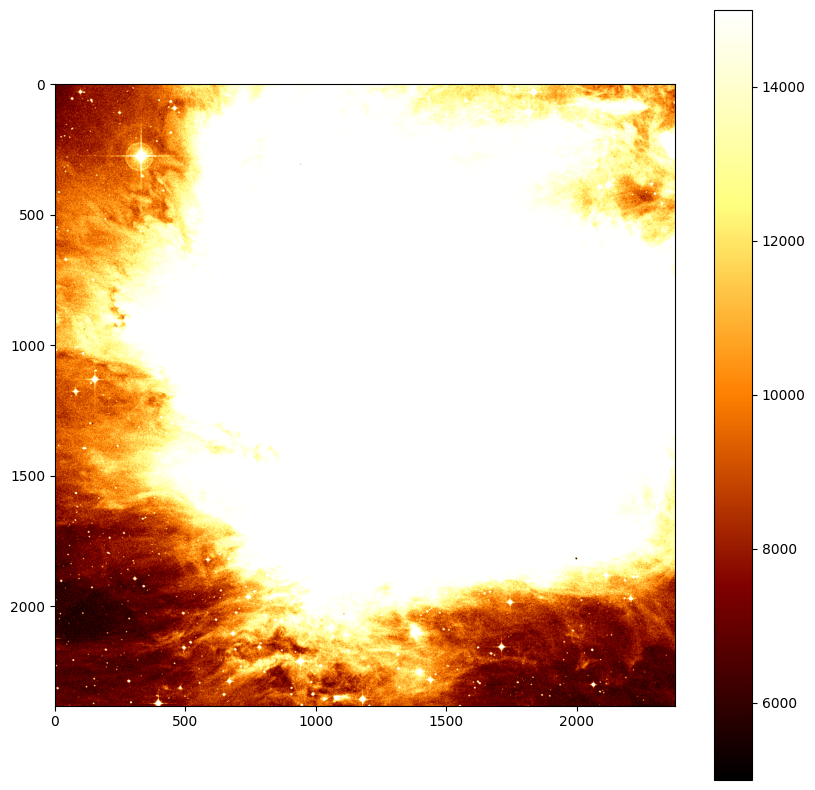

In [54]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='afmhot', vmin=5E3, vmax=1.5E4)
plt.colorbar()
plt.show()